### Basic Flux Surfaces

In [87]:
import jax_sbgeom as jsb
import jax.numpy as jnp
import jax 
jax.config.update("jax_enable_x64", True)

We first import the data from some VMEC file (we use a proprietary file here, but any can be used after converting to netcdf4)

In [88]:
from jax_sbgeom.flux_surfaces import FluxSurface

flux_surface = FluxSurface.from_hdf5("helias5_vmec.nc4")

Then, we can obtain positions from it easily:

In [90]:
flux_surface.cartesian_position(s = 1.0,  theta = 0.2, phi = 0.3)

Array([22.79398104,  7.05100461,  0.7066726 ], dtype=float64)

This base class does not go beyond the LCFS (same output):

In [91]:
flux_surface.cartesian_position(s = 2.0,  theta = 0.2, phi = 0.3)

Array([22.79398104,  7.05100461,  0.7066726 ], dtype=float64)

We can plot a poloidal slice (note that the all calls on the flux surface are completely vectorized in all arguments; you can pass in whatever shapes and it automatically works):

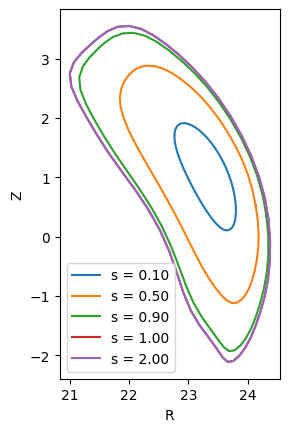

In [92]:
import matplotlib.pyplot as plt
def plot_poloidal_slice(flux_surface, phi, s_values, n_theta = 50):
    theta = jnp.linspace(0, 2 * jnp.pi, n_theta)
    s_mg, theta_mg = jnp.meshgrid(jnp.array(s_values), theta, indexing="ij")
    cylindrical_values = flux_surface.cylindrical_position(s_mg, theta_mg, phi)
    plt.figure()
    for i in range(cylindrical_values.shape[0]):
        
        plt.plot(cylindrical_values[i, :,0], cylindrical_values[i, :,1], label = f"s = {s_values[i]:.2f}")

    plt.gca().set_aspect('equal')
    plt.xlabel("R")
    plt.ylabel("Z")
    plt.legend()

plot_poloidal_slice(flux_surface, phi = 0.2, s_values = [0.1,0.5,0.9,1.0, 2.0])

For extending, we can create an extension and plot the same poloidal slice:

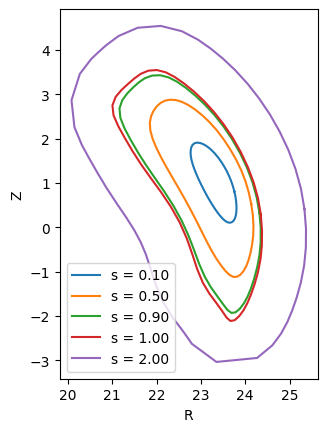

In [93]:
flux_surface_normal_extended = jsb.flux_surfaces.FluxSurfaceNormalExtended.from_flux_surface(flux_surface)
plot_poloidal_slice(flux_surface_normal_extended, phi = 0.2, s_values = [0.1,0.5,0.9,1.0, 2.0])

However, this has the problem that the $\varphi$ as input is not the same as the $\phi$ as output:

In [94]:
def check_same_phi(flux_surface, phi_in):
    print("Phi_in", phi_in)
    print("Phi_out", flux_surface.cylindrical_position(s = 2.0, theta = 0.0, phi = phi_in)[2])
    
check_same_phi(flux_surface_normal_extended, phi_in = 0.5)

Phi_in 0.5
Phi_out 0.4972359404296961


This has the issue that when Fourier transforming, we don't have an exact equidistant spacing in $\phi$ anymore.
This is fixed the following class:

In [95]:
flux_surface_normal_extended_no_phi = jsb.flux_surfaces.FluxSurfaceNormalExtendedNoPhi.from_flux_surface(flux_surface)

check_same_phi(flux_surface_normal_extended_no_phi, phi_in = 0.5)

Phi_in 0.5
Phi_out 0.5


Of course, the generated surfaces are then slightly different:

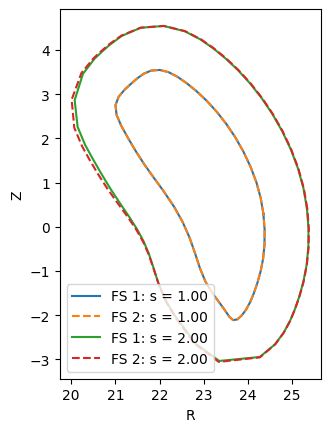

In [96]:
def plot_poloidal_slice_two_flux_surfaces(flux_surface_1, flux_surface_2, phi, s_values, n_theta = 50):
    theta = jnp.linspace(0, 2 * jnp.pi, n_theta)
    s_mg, theta_mg = jnp.meshgrid(jnp.array(s_values), theta, indexing="ij")
    cylindrical_values_1 = flux_surface_1.cylindrical_position(s_mg, theta_mg, phi)
    cylindrical_values_2 = flux_surface_2.cylindrical_position(s_mg, theta_mg, phi)
    plt.figure()
    for i in range(cylindrical_values_1.shape[0]):
        
        plt.plot(cylindrical_values_1[i, :,0], cylindrical_values_1[i, :,1], label = f"FS 1: s = {s_values[i]:.2f}")
        plt.plot(cylindrical_values_2[i, :,0], cylindrical_values_2[i, :,1], label = f"FS 2: s = {s_values[i]:.2f}", linestyle="dashed")

    plt.gca().set_aspect('equal')
    plt.xlabel("R")
    plt.ylabel("Z")
    plt.legend()

plot_poloidal_slice_two_flux_surfaces(flux_surface_normal_extended, flux_surface_normal_extended_no_phi, phi = 0.2, s_values = [1.0, 2.0])

Therefore, we lose the meaning that $s>1$ had: it no longer is the exact same distance as input.
Another class fixes this by doing Newton iterations to find $\overline{\varphi}(\varphi)$ such that $\varphi = \phi$ and then using the normal vector extension at $\overline{\varphi}(\varphi)$.

In [100]:
flux_surface_normal_extended_constant_phi = jsb.flux_surfaces.FluxSurfaceNormalExtendedConstantPhi.from_flux_surface(flux_surface)
check_same_phi(flux_surface_normal_extended_constant_phi, phi_in = 0.5)

Phi_in 0.5
Phi_out 0.5


In 3D, this defines the same surface as the FluxSurfaceNormalExtended! So the meaning is again the same: $s>1$ means distance to the LCFS.

However, naturally, we now lose that the extension beyond the LCFS is a straight line:

Text(0, 0.5, 'Z')

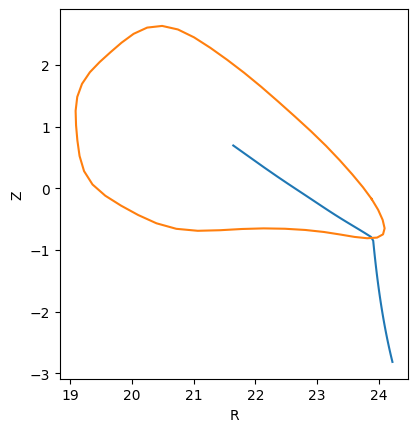

In [124]:
plt.figure()
positions_RZ = flux_surface_normal_extended_constant_phi.cylindrical_position(s = jnp.linspace(0,3.0, 50), theta = -0.7, phi = 0.5)

positions_slice = flux_surface_normal_extended_constant_phi.cylindrical_position(s = 1.0, theta = jnp.linspace(0, 2 * jnp.pi, 50), phi = 0.5)
plt.plot(positions_RZ[:,0], positions_RZ[:,1])
plt.plot(positions_slice[:,0], positions_slice[:,1])
plt.gca().set_aspect('equal')
plt.xlabel("R")
plt.ylabel("Z")

What is the most suitable depends on your application; sometimes you want straight extensions, sometimes defined offsets from the LCFS...